# Data Project - part 2.1 + 2.2

## Question 2.1 - The model

The life-cycle model is implemented in model_2_1.py. The module simulates 50,000 individuals from age 18 until retirement at age 65, including education, labor market transitions, human capital accumulation, and income. A fixed random seed is used to make the simulation reproducible.

**Imports:** We now import all the modules, we need for this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import model_2_1

**Results:** Some results from the simulation.

In [2]:
unique, counts = np.unique(
    model_2_1.education,
    return_counts=True
)

for edu, count in zip(unique, counts):
    print(edu, count / model_2_1.N)

print(model_2_1.income.shape)
print(model_2_1.human_capital.shape)

long 0.24852
medium 0.35142
short 0.40006
(50000, 47)
(50000, 47)


The simulated education shares are close to the specified probabilities of 0.40, 0.35, and 0.25 for short, medium, and long education, respectively. The income and human capital matrices both have dimensions 50,000 × 48, corresponding to 50,000 individuals observed annually from age 18 to 65.

## Question 2.2 - Simulate the income distribution

2.2.1

In [3]:
# a. education shares
unique, counts = np.unique(
    model_2_1.education,
    return_counts=True
)

simulated_shares = counts / model_2_1.N

for edu, share in zip(unique, simulated_shares):
    print(edu, share)

print("Target probabilities:", model_2_1.p_e)

long 0.24852
medium 0.35142
short 0.40006
Target probabilities: [0.4  0.35 0.25]


Result: The simulated education shares are very close to the specified probabilities p=(0.40,0.35,0.25), indicating that the education draw is implemented correctly.

In [4]:
# 2.2.1B: unemployment rate

# calculate the theoretical steady-state unemployment rate
steady_state_unemployment = (
    model_2_1.job_separation /
    (model_2_1.job_separation + model_2_1.job_finding)
)

print(steady_state_unemployment)

# create an empty list to store the unemployment rate for each age
unemployment_rate = []

# calculate the simulated unemployment rate over the life cycle
for t, age in enumerate(model_2_1.ages):

    # identify individuals who have entered the labor market
    in_labor_market = age >= model_2_1.entry_age

    # identify unemployed individuals in the labor market
    unemployed = (
        in_labor_market
        & ~model_2_1.employed[:, t]
    )

    # calculate unemployment rate only when the labor market is non-empty
    if in_labor_market.sum() > 0:
        rate = unemployed.sum() / in_labor_market.sum()
    else:
        rate = np.nan

    # store the unemployment rate for the current age
    unemployment_rate.append(rate)

0.07692307692307693


We run some prints to show that the simulated unemployment rate settles at the theoretical steady-state value.

In [5]:
# print simulated unemployment rates at selected ages
print("Age 30:", unemployment_rate[30 - 18])
print("Age 45:", unemployment_rate[45 - 18])
print("Age 60:", unemployment_rate[60 - 18])

Age 30: 0.07718
Age 45: 0.07774
Age 60: 0.07644


We find that the simulated unemployment rate settles close to the theoretical steady-state value of 7.69%. At ages 30, 45, and 60, the unemployment rate is approximately 7.72%, 7.77%, and 7.64%, respectively. This indicates that the simulated labor market transitions are consistent with the theoretical steady state.

2.2.2

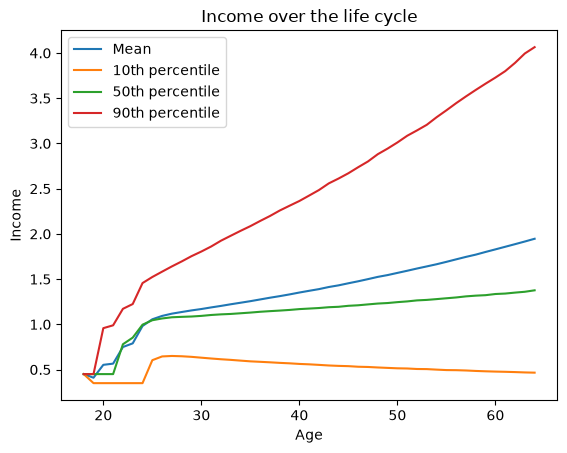

In [6]:
# 2.2.2 - mean and percentiles of income over the life cycle

# calculate mean income at each age
mean_income = np.mean(model_2_1.income, axis=0)

# calculate selected income percentiles at each age
p10_income = np.percentile(model_2_1.income, 10, axis=0)
p50_income = np.percentile(model_2_1.income, 50, axis=0)
p90_income = np.percentile(model_2_1.income, 90, axis=0)

# plot mean and selected percentiles of income over the life cycle

plt.plot(model_2_1.ages, mean_income, label='Mean')
plt.plot(model_2_1.ages, p10_income, label='10th percentile')
plt.plot(model_2_1.ages, p50_income, label='50th percentile')
plt.plot(model_2_1.ages, p90_income, label='90th percentile')

# add labels and title
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Income over the life cycle')

# add legend
plt.legend()

# show the figure
plt.show()

Analysis: 
The figure shows that income differences increase over the life cycle. At younger ages, incomes are relatively similar because many individuals are still in education and receive the student grant of 0.45. As individuals enter the labor market, the income distribution starts to spread out. In particular, the 90th percentile increases much faster than the median, as differences in human capital accumulate over time. At the same time, the 10th percentile decreases at older ages, partly reflecting unemployment and the depreciation of human capital. The mean therefore rises above the median, showing that high-income individuals increasingly pull up average income.

2.2.3

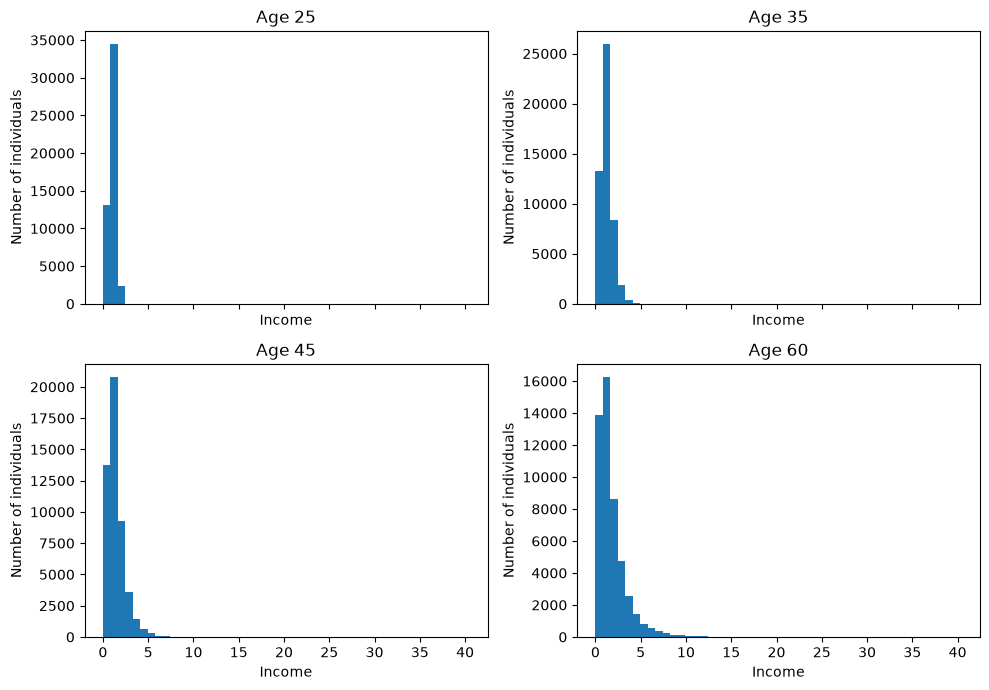

In [7]:
# 2.2.3: income distributions at selected ages

# select ages for the histograms
selected_ages = [25, 35, 45, 60]

# find the corresponding columns in the income matrix
age_indices = [age - 18 for age in selected_ages]

# create one figure with four histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

# use the same bins for all four histograms
bins = np.linspace(
    0,
    model_2_1.income[:, age_indices].max(),
    50
)

# plot income distribution at each selected age
for ax, age, index in zip(axes.flat, selected_ages, age_indices):

    ax.hist(model_2_1.income[:, index], bins=bins)

    ax.set_title(f'Age {age}')
    ax.set_xlabel('Income')
    ax.set_ylabel('Number of individuals')

# adjust spacing between the plots
plt.tight_layout()

# show the figure
plt.show()

Analysis: The income distribution becomes more dispersed over the life cycle. At age 25, incomes are still relatively concentrated, as many individuals have only recently entered the labor market. As individuals get older, the distribution gradually spreads out. In particular, the right tail becomes longer, meaning that some individuals develop much higher incomes than the majority. This also explains why the mean income becomes higher than the median, as the relatively few high incomes pull up the average. This reflects differences in human capital that accumulate over time. The income distribution therefore becomes more spread out with age, as a small group of individuals earns much higher incomes than the majority.